In [1]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


from process_ccf import process_ccf_dataset
from process_ccf import concat_ccf_csv_files



2026-04-24 14:35:54.317946: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 14:35:54.409133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777037754.444265   42448 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777037754.454814   42448 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777037754.536703   42448 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

From the notebook, you can run it with:

!python merge_snr_iccf_datasets.py
That will:

merge all CSVs with the same SNR
normalize those merged CCFs
save one parquet per SNR in CCFs/
save CCFs/random_rv_iccf_datasets_snr_merged_normalized.parquet
back up the old CCFs/full_iccf_dataset_normalized.parquet
overwrite CCFs/full_iccf_dataset_normalized.parquet with the combined dataset
If you want to only create the SNR parquet files and not touch the full parquet yet:

!python merge_snr_iccf_datasets.py --skip-append-to-full

In [ ]:
#!python merge_snr_iccf_datasets.py
#!python merge_snr_iccf_datasets.py --skip-append-to-full



Found 2156 CSV files across 22 SNR groups.
/home/vadibekyan/Exoplanets/scientific_projects/AI/RV/DL_RV_diogo/merge_snr_iccf_datasets.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["dataset_label"] = f"active_snr_{snr}"
SNR 20p0: 98 files -> 9800 rows
/home/vadibekyan/Exoplanets/scientific_projects/AI/RV/DL_RV_diogo/merge_snr_iccf_datasets.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["dataset_label"] = f"active_snr_{snr}"
SNR 25p0: 98 files -> 9800 rows
/home/vadibekyan/Exoplanets/scientific_pr

In [ ]:
#quiet_output_file = "./CCFs/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1_normalized.parquet"
#merged_input_dir = "./hpc_results/random_rv_iccf_datasets_1000"
#merged_csv_file = "./hpc_results/random_rv_iccf_datasets_1000_merged.csv"
#merged_output_file = "./CCFs/random_rv_iccf_datasets_1000_merged_normalized.parquet"

#merged_df = concat_ccf_csv_files(
#    merged_input_dir,
#    output_path=merged_csv_file,
#)

In [ ]:
#process_ccf_dataset(merged_csv_file, merged_output_file)

Loading hpc_results/random_rv_iccf_datasets_1000_merged.csv...
Rounded rv_true_mps to 2 decimals
Normalized CCFs
Rounded CCFs to 4 decimals
Saving to CCFs/random_rv_iccf_datasets_1000_merged_normalized.parquet...
Done!


In [3]:
full_df = pd.read_parquet("./CCFs/random_rv_iccf_datasets_snr_merged_normalized.parquet")
full_df
                          

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0299,ccf_0300,snr,activity,fixed_seed,fixed_seed_id,source_folder,source_file,ccf_descriptor,dataset_label
0,82.01,-144.097125,6.599835,-35.005783,-26.788041,-606.359591,56.696423,0.9782,0.9781,0.9783,...,0.9882,0.9879,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
1,29.20,-196.915108,6.600317,-35.108102,-25.532521,-607.916255,56.697067,0.9781,0.9782,0.9784,...,0.9881,0.9876,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
2,75.02,-151.093671,6.599898,-35.037001,-26.639270,-606.509978,56.696505,0.9782,0.9781,0.9783,...,0.9882,0.9878,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
3,2.57,-223.542203,6.600578,-34.946434,-27.274065,-604.621989,56.697316,0.9781,0.9782,0.9785,...,0.9880,0.9875,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
4,49.21,-176.906858,6.600132,-35.139980,-26.118377,-607.225668,56.696813,0.9782,0.9781,0.9783,...,0.9882,0.9877,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015195,98.75,-125.479807,6.597406,-35.081919,-28.666788,-602.829436,56.711306,0.9788,0.9788,0.9788,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0
2015196,91.67,-132.557164,6.597474,-35.106180,-28.471795,-602.866726,56.711361,0.9788,0.9788,0.9788,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0
2015197,72.85,-151.381449,6.597646,-35.184436,-27.978022,-602.998998,56.711557,0.9788,0.9788,0.9788,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0
2015198,14.19,-210.036410,6.598196,-35.057732,-29.117631,-601.425394,56.712236,0.9788,0.9788,0.9787,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0


In [4]:
set(full_df['snr'])

{'100p0',
 '125p0',
 '150p0',
 '20p0',
 '250p0',
 '25p0',
 '300p0',
 '30p0',
 '35p0',
 '400p0',
 '40p0',
 '45p0',
 '500p0',
 '50p0',
 '60p0',
 '70p0',
 '800p0',
 '80p0',
 '90p0'}

In [5]:
full_df[full_df['snr'] == '100p0']

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0299,ccf_0300,snr,activity,fixed_seed,fixed_seed_id,source_folder,source_file,ccf_descriptor,dataset_label
877360,51.18,-173.313973,6.598065,-35.367020,-27.323339,-604.382675,56.710811,0.9790,0.9789,0.9790,...,0.9885,0.9883,100p0,plage,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=100p0|fixed_seed1|random_rv_iccf_ar1...,active_snr_100p0
877361,95.05,-129.445956,6.597663,-35.177906,-28.395864,-603.854400,56.710320,0.9790,0.9790,0.9789,...,0.9885,0.9884,100p0,plage,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=100p0|fixed_seed1|random_rv_iccf_ar1...,active_snr_100p0
877362,14.42,-210.082052,6.598417,-35.139370,-28.943436,-602.374057,56.711227,0.9790,0.9789,0.9790,...,0.9884,0.9883,100p0,plage,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=100p0|fixed_seed1|random_rv_iccf_ar1...,active_snr_100p0
877363,94.86,-129.627387,6.597665,-35.178552,-28.391002,-603.855802,56.710322,0.9790,0.9790,0.9789,...,0.9885,0.9884,100p0,plage,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=100p0|fixed_seed1|random_rv_iccf_ar1...,active_snr_100p0
877364,31.18,-193.314815,6.598256,-35.445020,-26.857443,-604.826689,56.711048,0.9790,0.9789,0.9790,...,0.9884,0.9883,100p0,plage,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=100p0|fixed_seed1|random_rv_iccf_ar1...,active_snr_100p0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983395,36.98,-187.317360,6.598746,-34.451137,-26.141754,-600.736424,56.705667,0.9785,0.9786,0.9786,...,0.9876,0.9876,100p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=100p0|random_seed|random_rv_iccf_ar1_...,active_snr_100p0
983396,57.39,-166.912287,6.598557,-34.364231,-26.606659,-600.366942,56.705428,0.9785,0.9786,0.9786,...,0.9876,0.9876,100p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=100p0|random_seed|random_rv_iccf_ar1_...,active_snr_100p0
983397,37.77,-186.531573,6.598738,-34.448074,-26.159889,-600.719425,56.705659,0.9785,0.9786,0.9786,...,0.9876,0.9876,100p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=100p0|random_seed|random_rv_iccf_ar1_...,active_snr_100p0
983398,4.62,-219.682636,6.599055,-34.197022,-27.812723,-598.612548,56.705997,0.9786,0.9786,0.9787,...,0.9876,0.9876,100p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=100p0|random_seed|random_rv_iccf_ar1_...,active_snr_100p0


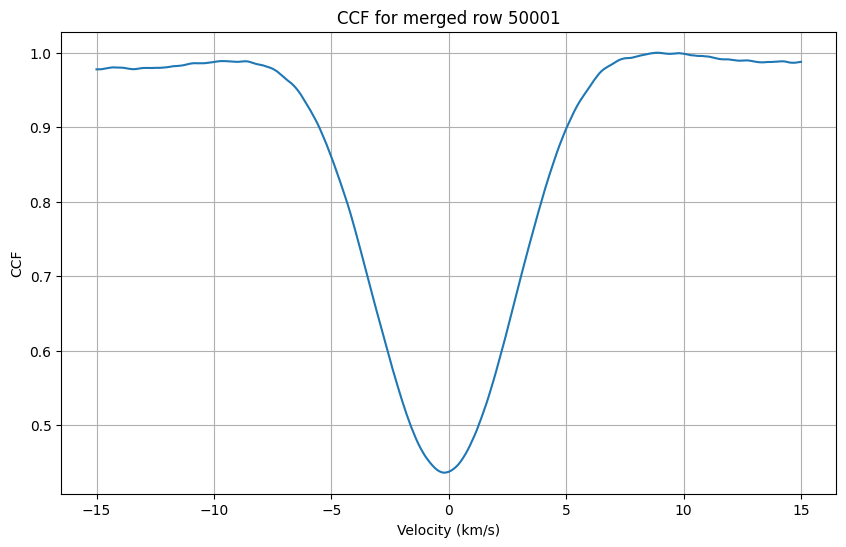

In [6]:
# Plot CCF for a given row
row_index = 50001  # Change this to the desired row index
velocities = np.arange(-15, 15.1, 0.1)
ccf_columns = [f'ccf_{i:04d}' for i in range(301)]
ccf_values = full_df.loc[row_index, ccf_columns].values

plt.figure(figsize=(10, 6))
plt.plot(velocities, ccf_values)
plt.xlabel('Velocity (km/s)')
plt.ylabel('CCF')
plt.title(f'CCF for merged row {row_index}')
plt.grid(True)
plt.show()

In [7]:
ccf_cols = [c for c in full_df.columns if c.startswith("ccf_")]

X = full_df[ccf_cols].to_numpy(dtype=np.float32)
y = pd.to_numeric(full_df["rv_true_mps"], errors="coerce").to_numpy(dtype=np.float32).reshape(-1, 1)

ValueError: could not convert string to float: 'plage|snr=20p0|random_seed|random_rv_iccf_ar1_plage_lonm0p391728_latp11p145_size0p0121969_dT295p531_real0000'

In [14]:
# Split merged quiet+active dataset into train/dev/test: 70% / 15% / 15%
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, shuffle=True
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Dev:  ", X_dev.shape, y_dev.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (521920, 301) (521920, 1)
Dev:   (111840, 301) (111840, 1)
Test:  (111840, 301) (111840, 1)


In [15]:
# Scale features and target for stable training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_dev_s = x_scaler.transform(X_dev)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train)
y_dev_s = y_scaler.transform(y_dev)
y_test_s = y_scaler.transform(y_test)


In [16]:
# Simple MLP baseline
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(64, activation="relu"),
    #layers.Dropout(0.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.7,
        patience=10,
        min_lr=1e-5,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]


history = model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_dev_s, y_dev_s),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


2026-04-13 13:13:01.202459: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0627 - mae: 0.1384 - val_loss: 0.0090 - val_mae: 0.0671 - learning_rate: 0.0010
Epoch 2/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0107 - mae: 0.0675 - val_loss: 0.0097 - val_mae: 0.0669 - learning_rate: 0.0010
Epoch 3/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0084 - mae: 0.0554 - val_loss: 0.0067 - val_mae: 0.0469 - learning_rate: 0.0010
Epoch 4/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0071 - mae: 0.0489 - val_loss: 0.0069 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 5/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0063 - mae: 0.0446 - val_loss: 0.0054 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 6/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0057 - mae: 0.0409 - val_loss: 0.0051 - val_mae: 0.0365 - learning_rate: 0.0010
Epoch 7/50
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0053 - mae: 0.0382 - val_loss: 0.0048 - val_mae: 0.0341 - learnin

In [17]:
def evaluate_regression(model, X_s, y_true, scaler, split_name):
    y_pred_s = model.predict(X_s, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_s).ravel()
    y_true = y_true.ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)

    print(f"{split_name} -> MAE: {mae:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return y_pred

y_dev_pred = evaluate_regression(model, X_dev_s, y_dev, y_scaler, "Dev")
y_test_pred = evaluate_regression(model, X_test_s, y_test, y_scaler, "Test")


Dev -> MAE: 0.470713, RMSE: 0.691750, R2: 0.999409
Test -> MAE: 0.468415, RMSE: 0.688086, R2: 0.999412


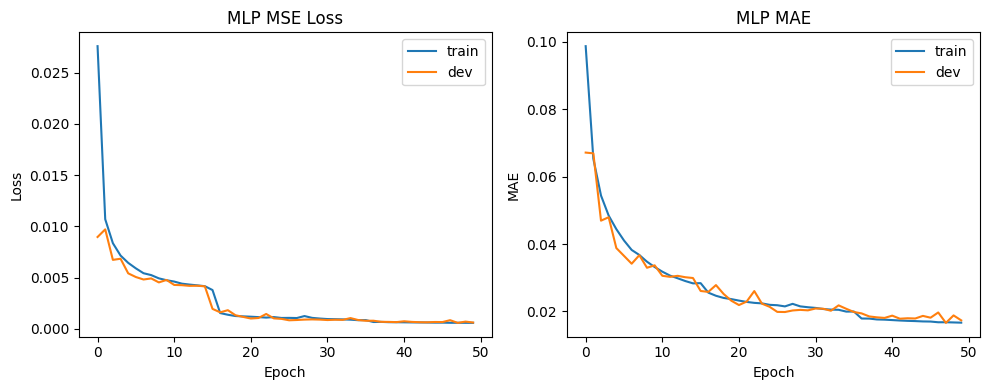

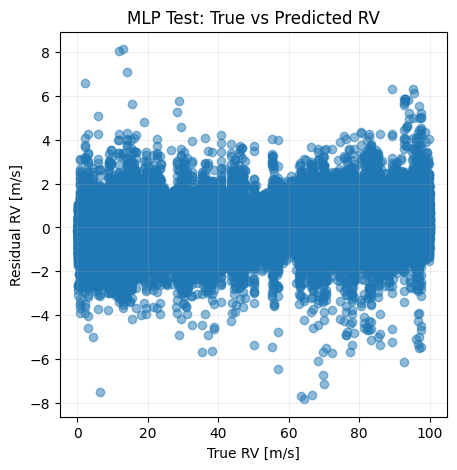

In [18]:
# MLP training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="dev")
plt.title("MLP MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="dev")
plt.title("MLP MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# MLP prediction scatter on test split
plt.figure(figsize=(5, 5))
plt.scatter(y_test.ravel(), y_test.ravel() - y_test_pred, alpha=0.5)
min_v = min(y_test.min(), y_test_pred.min())
max_v = max(y_test.max(), y_test_pred.max())
#plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual RV [m/s]")
plt.title("MLP Test: True vs Predicted RV")
plt.grid(True, alpha=0.2)
plt.show()
